In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df = df.drop(['UDI' , 'Product ID' , 'Type','TWF', 'HDF', 'PWF', 'OSF', 'RNF'],axis = 1)

In [4]:
print(df.isnull().sum())

Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air temperature [K]      10000 non-null  float64
 1   Process temperature [K]  10000 non-null  float64
 2   Rotational speed [rpm]   10000 non-null  int64  
 3   Torque [Nm]              10000 non-null  float64
 4   Tool wear [min]          10000 non-null  int64  
 5   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 468.9 KB


In [6]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


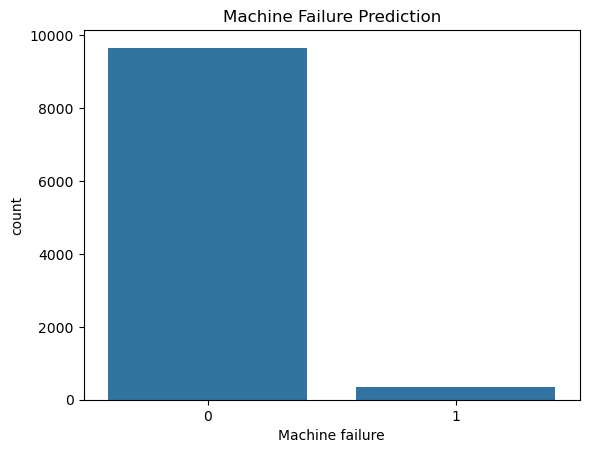

In [7]:
sns.countplot(x = 'Machine failure' ,  data = df)
plt.title('Machine Failure Prediction')
plt.show()

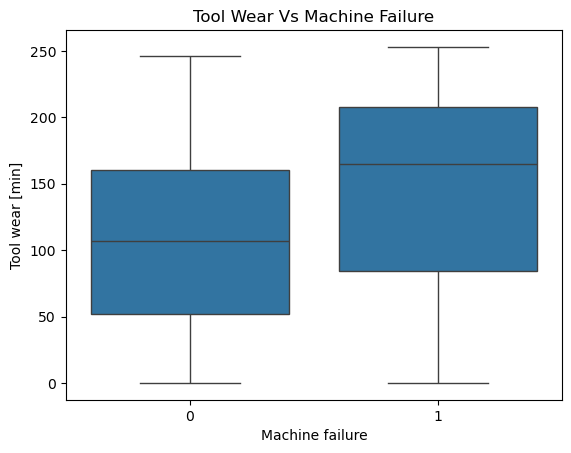

In [8]:
sns.boxplot(x = 'Machine failure' , y = 'Tool wear [min]' , data = df)
plt.title('Tool Wear Vs Machine Failure')
plt.show()

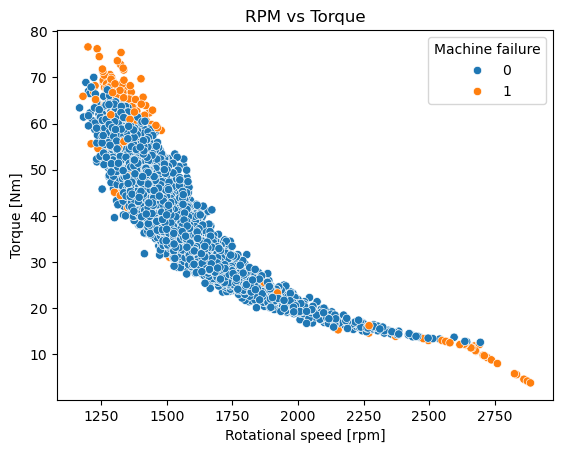

In [9]:
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]', 
                hue='Machine failure', data=df)
plt.title("RPM vs Torque")
plt.show()

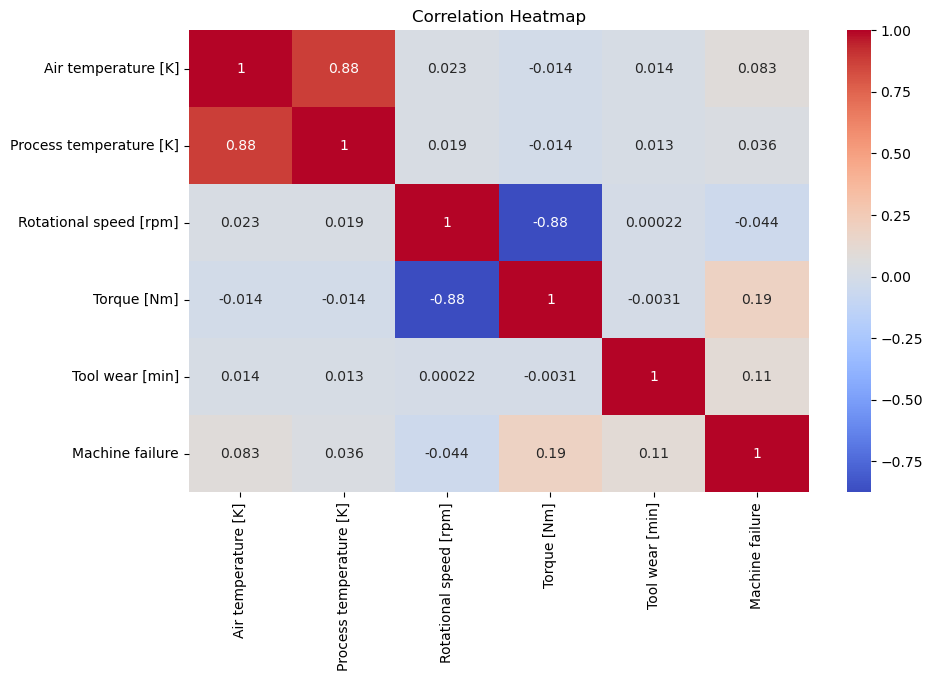

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [11]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state = 42)

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight = 'balanced',random_state = 42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_predict = model.predict(X_test)

In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test , y_predict))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.88      0.46      0.60        61

    accuracy                           0.98      2000
   macro avg       0.93      0.73      0.80      2000
weighted avg       0.98      0.98      0.98      2000



In [16]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_predict))

[[1935    4]
 [  33   28]]


In [17]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Average Accuracy:", scores.mean())

Average Accuracy: 0.9524000000000001


In [20]:
# USER INPUT

air_temp = float(input("Enter Air Temperature (K): "))
process_temp = float(input("Enter Process Temperature (K): "))
rpm = float(input("Enter Rotational Speed (rpm): "))
torque = float(input("Enter Torque (Nm): "))
wear = float(input("Enter Tool Wear (min): "))

# PREPARE DATA (FIXED)

import pandas as pd

data = pd.DataFrame([{
    'Air temperature [K]': air_temp,
    'Process temperature [K]': process_temp,
    'Rotational speed [rpm]': rpm,
    'Torque [Nm]': torque,
    'Tool wear [min]': wear
}])

# PREDICTION

prediction = model.predict(data)[0]
prob = model.predict_proba(data)[0][1]

# OUTPUT

print("\n===== DIGITAL TWIN OUTPUT =====")

if prediction == 1:
    print(" Machine Failure Likely")
else:
    print(" Machine is Safe")

print(f"Failure Probability: {prob:.2f}")

# RISK LEVEL

if prob > 0.7:
    print(" Risk Level: HIGH")
elif prob > 0.4:
    print(" Risk Level: MEDIUM")
else:
    print(" Risk Level: LOW")


Enter Air Temperature (K):  305
Enter Process Temperature (K):  310
Enter Rotational Speed (rpm):  1600
Enter Torque (Nm):  45
Enter Tool Wear (min):  200



===== DIGITAL TWIN OUTPUT =====
 Machine is Safe
Failure Probability: 0.02
 Risk Level: LOW


In [21]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))